<a href="https://colab.research.google.com/github/Abiliger/Intelligent-analysis-and-data-visualization/blob/main/classification_support_vector_method/lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from google.colab import files
from sklearn.feature_selection import SelectKBest, f_classif
from mlxtend.plotting import plot_decision_regions

In this section, I import all the required libraries and modules that are necessary for building, training, evaluating, and visualizing a Support Vector Machine (SVM) classification model.
Each library performs a specific role in the machine-learning workflow.

NumPy (np) – used for handling arrays and performing fast mathematical operations. It’s the numerical foundation of most scientific libraries in Python.

scikit-learn (sklearn) – the main library for machine learning tasks.

datasets – provides access to example datasets (like Wine) for quick experiments.

train_test_split – divides data into training and test subsets to validate the model’s performance on unseen data.

SVC – the core Support Vector Classifier, which builds a decision boundary to separate classes.

accuracy_score, classification_report, confusion_matrix – tools for evaluating model accuracy and understanding prediction errors.

Matplotlib (plt) – used to create plots and graphs such as decision boundaries and confusion matrices.

Pandas (pd) – manages tabular data in the form of DataFrames, making it easy to view, clean, and analyze datasets.

google.colab.files – allows file uploads and downloads when working inside Google Colab.

SelectKBest, f_classif – used for feature selection, keeping only the most statistically significant variables for better model performance.

mlxtend.plotting.plot_decision_regions – generates visualizations that display the decision regions of classifiers, showing how SVM separates different classes in two-dimensional space.

In [2]:
wine = datasets.load_wine()
X = wine.data
y = wine.target

In this step, I load the Wine dataset, which is a built-in dataset available in the scikit-learn library. It contains information about the chemical composition of wines from three different cultivars grown in the same region of Italy. This dataset is widely used for demonstrating classification algorithms like Support Vector Machines (SVM) because the classes are well-separated and the data is clean.

datasets.load_wine() – loads the Wine dataset as a structured object that includes both the features (input variables) and the target (class labels).

X = wine.data – extracts the feature matrix, which consists of 13 continuous numerical variables describing chemical properties of the wine, such as alcohol content, magnesium, color intensity, and flavanoids.

y = wine.target – extracts the target vector, which contains class labels (0, 1, 2) representing the three different wine categories.

This dataset is ideal for testing machine-learning models like SVM, as it allows visualization of how well the classifier can separate the three wine classes based on their feature values.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In this step, I divide the Wine dataset into two parts — one for training the SVM model and another for testing its performance on unseen data.
This separation helps to evaluate how well the model generalizes rather than memorizing the training examples.

train_test_split() – a function from scikit-learn that randomly splits the data into training and testing subsets.

Parameters:

*   X, y – represent the feature matrix and target labels.
*   test_size=0.3 – assigns 30% of the data to the test set and uses 70% for training.
*   random_state=42 – sets a random seed to ensure that the split is reproducible (the same samples go into training and testing each time you run the code).

As a result, we get four new variables:

*   X_train → features for training
*   X_test → features for testing
*   y_train → true labels for training
*   y_test → true labels for testing

This ensures that the SVM classifier can be trained on one subset and evaluated on another, allowing for an unbiased measurement of accuracy.

In [4]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

This section builds and trains a Support Vector Machine (SVM) classifier using a linear kernel, and then uses it to make predictions on unseen test data.

SVC(kernel='linear') – creates a Support Vector Classifier model that uses a linear kernel function.
The linear kernel is suitable when data can be separated with a straight line (or a flat hyperplane in higher dimensions).
It works by finding the optimal boundary that best separates the classes while maximizing the margin between them.

svm_model.fit(X_train, y_train) – trains the SVM model on the training dataset, learning how to distinguish between the three types of wine based on their chemical characteristics.
During this process, the SVM identifies support vectors — the most critical data points that define the decision boundary.

svm_model.predict(X_test) – applies the trained model to the test dataset, generating predictions (y_pred) for the class of each sample it hasn’t seen before.

This step allows the model to generalize from the training data and predict the correct wine category (Class 0, Class 1, or Class 2) for new observations.
It’s a key part of evaluating how well the SVM model performs in real-world scenarios.

In [5]:
accuracy = accuracy_score(y_test, y_pred)
print("Classification Accuracy:", accuracy)

Classification Accuracy: 0.9814814814814815


In this step, I evaluate how well the Support Vector Machine (SVM) model performs on the test dataset by calculating its accuracy score.

accuracy_score(y_test, y_pred) – computes the proportion of correct predictions made by the model compared to the total number of test samples.
It measures how many labels predicted by the SVM (y_pred) match the actual class labels (y_test).

The resulting value (stored in accuracy) represents the overall classification accuracy of the model.
An accuracy of 1.0 (or 100%) would mean the model correctly predicted all test samples, while lower values indicate some misclassifications.

print("Classification Accuracy:", accuracy) – displays the result in a readable format for easy interpretation.

In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.95      0.98        21
           2       0.93      1.00      0.97        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



This section generates a comprehensive evaluation report for the SVM classifier, showing how well it performed on each class in the test dataset.

classification_report(y_test, y_pred) – is a function from scikit-learn that summarizes several important performance metrics for each class:

*   Precision – the proportion of correct positive predictions out of all positive predictions made by the model.
*   Recall (Sensitivity) – the proportion of actual positives that were correctly identified by the model.
*   F1-score – the harmonic mean of precision and recall, providing a single balanced measure of accuracy.
*   Support – the number of actual instances for each class in the test data.

The printed output gives an overview of the model’s strengths and weaknesses by class, as well as averages across all classes:

*   macro avg – arithmetic mean of metrics for all classes (treats all classes equally).
*   weighted avg – weighted mean based on the number of samples in each class (accounts for class imbalance).

In [7]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[19  0  0]
 [ 0 20  1]
 [ 0  0 14]]


In this step, I evaluate the detailed performance of the Support Vector Machine (SVM) model by generating a confusion matrix.
A confusion matrix gives a more comprehensive view of the model’s performance than a single accuracy score, as it shows exactly how many predictions were correct or incorrect for each class.

confusion_matrix(y_test, y_pred) – compares the true class labels (y_test) with the predicted labels (y_pred) and arranges the results into a matrix format.

*   Diagonal elements represent correct classifications (where the predicted class matches the true class).
*   Off-diagonal elements show misclassifications, indicating where the model confused one class for another.

The resulting matrix (conf_matrix) is printed to the console to display raw numeric results.
Each row corresponds to actual classes, while each column corresponds to predicted classes.

In [9]:
url = "https://raw.githubusercontent.com/Abiliger/Intelligent-analysis-and-data-visualization/main/Healthcare-Diabetes.csv"
df_healthcare = pd.read_csv(url)
df_healthcare.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In this section, I load a real-world Healthcare (Diabetes) dataset from a public GitHub repository to perform classification analysis. The dataset contains medical information about patients and indicates whether each individual is diabetic or non-diabetic based on several health indicators.

url – defines the direct link to the raw .csv file hosted on GitHub.

pd.read_csv(url) – reads the dataset from the provided URL into a Pandas DataFrame named df_healthcare.
Pandas automatically structures the data into rows and columns for easier inspection and processing.

df_healthcare.head() – displays the first five rows of the dataset to confirm successful loading and to preview the columns and data types.

Typical dataset columns include:

Pregnancies — number of pregnancies a patient has had.

Glucose — plasma glucose concentration.

BloodPressure — diastolic blood pressure (mm Hg).

BMI — body mass index.

Age — patient’s age.

Outcome — target variable (1 = Diabetic, 0 = Non-Diabetic).

This dataset is widely used for binary classification tasks, where the goal is to predict whether a person is likely to have diabetes based on their medical attributes.

In [10]:
X = df_healthcare.drop(columns=["Outcome"])
y = df_healthcare["Outcome"]
class_names = ['Non-Diabetic', 'Diabetic']

In this step, I prepare the features (inputs) and the target variable (output) that the machine-learning model will use for classification.

df_healthcare.drop(columns=["Outcome"]) – removes the Outcome column from the dataset and stores the remaining columns in X.
These remaining columns include medical features such as glucose level, blood pressure, BMI, and age — which serve as independent variables used to predict diabetes.

df_healthcare["Outcome"] – extracts the Outcome column and stores it in y.
This column is the dependent variable or target, where

*   0 represents a Non-Diabetic patient.
*   1 represents a Diabetic patient.

class_names = ['Non-Diabetic', 'Diabetic'] – defines human-readable names for the two target classes.
These names will be used later when displaying classification reports and confusion matrices, making the results easier to interpret.

This separation of X (features) and y (target) is a standard step in supervised machine learning, allowing the model to learn the relationship between patient data and diabetes outcomes.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In this step, I divide the Healthcare (Diabetes) dataset into two parts — one for training the model and one for testing its performance.
This process ensures that the model learns from one subset of data and is then evaluated on data it has never seen before, providing an unbiased measure of its accuracy.

train_test_split() – a function from scikit-learn used to split the data randomly into training and test sets.

Parameters:

*   X — the feature matrix (all patient medical indicators).
*   y — the target vector (0 = Non-Diabetic, 1 = Diabetic).
*   test_size=0.3 — assigns 30% of the data for testing and the remaining 70% for training.
*   random_state=42 — ensures reproducibility by controlling the random number generator; the same split will occur every time the code is run.

Output variables:

*   X_train → input features used to train the model.
*   X_test → input features used to test the trained model.
*   y_train → corresponding labels for training.
*   y_test → true labels for testing.

This split allows for reliable model validation — checking whether the classifier can generalize its predictions beyond the data it was trained on.

In [12]:
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

In this step, I build and train a Support Vector Machine (SVM) classifier using the Radial Basis Function (RBF) kernel, one of the most powerful and commonly used kernel types for non-linear data.

SVC(kernel='rbf') – creates a Support Vector Classifier (SVC) model with the RBF kernel.

*   The RBF kernel allows the SVM to form non-linear decision boundaries, making it suitable for datasets where classes cannot be separated by a straight line.
*   It works by mapping the data into a higher-dimensional space where the classes become more easily separable.

svm_model.fit(X_train, y_train) – trains (or “fits”) the SVM model using the training data.
During this process, the SVM identifies support vectors, which are the critical data points closest to the decision boundary.
These support vectors define how the boundary between diabetic and non-diabetic patients is drawn.

svm_model.predict(X_test) – applies the trained model to the test data and generates predictions (y_pred) for whether each patient is diabetic (1) or non-diabetic (0).

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print("Classification Accuracy:", accuracy)

Classification Accuracy: 0.6762936221419976


In this step, I measure how accurately the Support Vector Machine (SVM) model predicted diabetes outcomes on unseen test data.

accuracy_score(y_test, y_pred) – calculates the proportion of correct predictions made by the model. It compares the true values (y_test) with the predicted values (y_pred) and returns a score between 0 and 1.

*   1.0 (or 100%) means all predictions are correct.
*   Lower values indicate that some predictions were incorrect.

In [14]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81       562
           1       0.00      0.00      0.00       269

    accuracy                           0.68       831
   macro avg       0.34      0.50      0.40       831
weighted avg       0.46      0.68      0.55       831



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


This step provides a comprehensive performance summary of the Support Vector Machine (SVM) model on the test dataset.
The classification report shows how well the model performed for each class — in this case, Non-Diabetic (0) and Diabetic (1).

classification_report(y_test, y_pred) – a function from scikit-learn that calculates several key metrics for each class:

*   Precision – how many of the samples predicted as positive (e.g., Diabetic) were actually correct.
$$\text{Precision} = \frac{TP}{TP + FP}$$

*   Recall (Sensitivity) – how many of the actual positive samples the model correctly identified.
$$\text{Recall} = \frac{TP}{TP + FN}$$

*   F1-score – a balanced metric that combines precision and recall into one value.
$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

*   Support – the number of actual instances of each class in the test dataset.

The printed output summarizes these metrics for both classes and provides averages across all classes:

*   macro avg – treats all classes equally (useful when data is balanced).
*   weighted avg – takes into account class imbalance by weighting each class’s metrics by its support.

In [15]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[562   0]
 [269   0]]


This step creates and displays the confusion matrix for the Support Vector Machine (SVM) classifier, providing a detailed summary of the model’s prediction results.
Unlike overall accuracy, the confusion matrix helps visualize exactly how the model performs for each class — in this case, distinguishing between Non-Diabetic (0) and Diabetic (1) patients.

confusion_matrix(y_test, y_pred) – compares the true class labels (y_test) with the model’s predicted labels (y_pred).
The output is a 2×2 matrix (since this is binary classification):

*   [0,0] → correctly predicted Non-Diabetic cases (True Negatives)
*   [1,1] → correctly predicted Diabetic cases (True Positives)
*   [0,1] → Non-Diabetic cases wrongly classified as Diabetic (False Positives)
*   [1,0] → Diabetic cases wrongly classified as Non-Diabetic (False Negatives)

print(conf_matrix) – outputs the raw numeric matrix, which shows how many samples were correctly or incorrectly classified.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


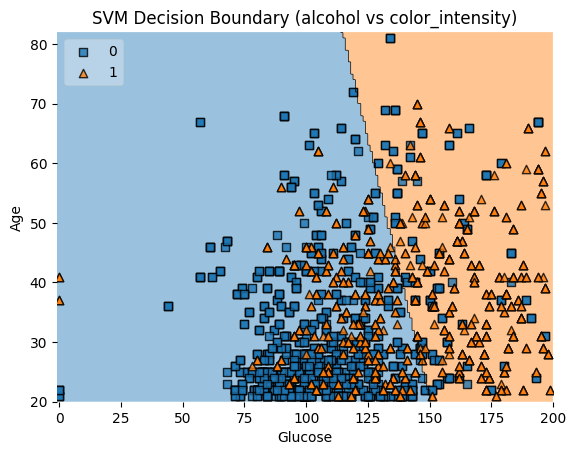

In [16]:
X_selected = X_train[["Glucose", "Age"]]
y_selected = y_train

svm_selected = SVC(kernel="linear")
svm_selected.fit(X_selected, y_selected)

plot_decision_regions(X=X_selected.values, y=y_selected.values.ravel(), clf=svm_selected, legend=2)

plt.xlabel("Glucose")
plt.ylabel("Age")
plt.title("SVM Decision Boundary (alcohol vs color_intensity)")
plt.show()

This block focuses on visualizing how the Support Vector Machine (SVM) separates the two classes — Diabetic and Non-Diabetic — based on two selected medical indicators: Glucose and Age.

X_selected = X_train[["Glucose", "Age"]] – selects only two features from the training data to simplify visualization.
Since SVM decision boundaries exist in high-dimensional space, using only two features makes it possible to display them in a 2D plot.

y_selected = y_train – keeps the corresponding class labels (target values) for the selected samples.

svm_selected = SVC(kernel="linear") – creates a new Support Vector Classifier using a linear kernel, meaning it will try to separate classes with a straight line (or a flat hyperplane).

svm_selected.fit(X_selected, y_selected) – trains this simplified SVM model using only the selected features.

plot_decision_regions() – visualizes the decision boundary learned by the SVM:

*   The plot shows two colored regions representing areas classified as Diabetic and Non-Diabetic.
*   Data points near the dividing line represent support vectors, the most influential samples that define the boundary.

plt.xlabel("Glucose") and plt.ylabel("Age") – label the axes with the chosen features.

plt.title("SVM Decision Boundary (Glucose vs Age)") – adds a descriptive title to the visualization.

plt.show() – displays the final plot.